# Tomato Vision — IS794 Project Code

Notebook proyek: akuisisi dan audit dataset, EDA, preprocessing, CNN dari nol,
training yang dapat diulang, evaluasi validation, analisis kesalahan, dan inferensi.

**Status:** 300 gambar dalam paket; 60 anotasi lama disetujui, 218 sintetis, 22 impor belum berlabel.
Jumlah 300 belum membuktikan syarat 100 gambar primer. Asal kamera 60 gambar lama belum dikonfirmasi ulang.
Hasil lama own_v1 mengalami kebocoran sesi dan tidak digunakan sebagai hasil utama.
Identitas tim digabungkan pemilik dari dokumen terpisah.

Ekstrak ZIP proyek, buat Python 3.11 environment, lalu `pip install -r requirements-submission.txt`.
Jalankan dari root proyek atau folder `notebooks`. Sel default membaca model tersimpan;
ubah `RUN_TRAINING=True` untuk mengulang dua eksperimen pada direktori baru.
Test terkunci tidak dibuka oleh notebook ini. Sudah dieksekusi lokal; Colab belum diuji.

## 1. Persiapan dan pemulihan data dari paket

In [1]:
from pathlib import Path
import os, sys, json, csv, hashlib, shutil, zipfile
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/model.py").exists()), None)
assert ROOT is not None, "Ekstrak ZIP proyek lengkap, lalu jalankan dari root proyek."
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "outputs/.matplotlib"))
DATA = ROOT / "submission/dataset"
if not (DATA / "images").exists():
    archive = DATA / "TomatoVision_Dataset.zip"
    assert archive.exists(), "Dataset ZIP belum tersedia."
    with zipfile.ZipFile(archive) as z:
        for name in z.namelist():
            assert (DATA / name).resolve().is_relative_to(DATA.resolve()), "Path ZIP tidak aman"
        z.extractall(DATA)
labels = list(csv.DictReader((DATA / "labels.csv").open()))
for row in labels:
    image = DATA / row["file"]
    assert hashlib.sha256(image.read_bytes()).hexdigest() == row["sha256"]
    if row["source"] == "own" and row["review_status"] == "approved":
        target = ROOT / "data/raw" / row["original_name"]
        target.parent.mkdir(parents=True, exist_ok=True)
        if not target.exists(): shutil.copy2(image, target)
        assert hashlib.sha256(target.read_bytes()).hexdigest() == row["sha256"]
print("Paket:", len(labels), "gambar unik; semua hash cocok.")

Paket: 127 gambar unik; semua hash cocok.


## 2. Akuisisi, kurasi, dan data primer
Metadata sumber dipertahankan. AI dan augmentasi tidak dihitung sebagai bukti data primer. Foto impor dikelompokkan konservatif karena identitas buah lintas hari belum pasti. Label model bukan ground truth.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
inventory = pd.DataFrame(labels)
display(inventory.groupby(["source", "review_status"]).size().rename("jumlah").to_frame())
print("Berlabel:", inventory.label.ne("").sum(), "belum berlabel:", inventory.label.eq("").sum())
print("Kandidat sumber non-AI:", inventory.source.ne("synthetic_ai").sum(), "(asal primer perlu bukti)")
assert inventory.sha256.is_unique
assert (inventory.loc[inventory.source.eq("synthetic_ai"), "approved"] == "False").all()

jumlah
source       review_status                                             
own          awaiting_owner_condition_label                          22
             existing_approved_annotation                            60
synthetic_ai assistant_visual_review_pending_human_label_review      45

Berlabel: 105 belum berlabel: 22
Kandidat sumber non-AI: 82 (asal primer perlu bukti)


## 3. Split sesi beku dan pemeriksaan kebocoran
48 training / 6 validation / 6 test. Satu grup tidak boleh masuk beberapa split. Hash test tetap mengikuti protokol yang dibekukan; hanya metadata test dibaca di sini.

label,segar,tidak_segar,busuk
split,,,
train,16,16,16
val,2,2,2
test,2,2,2


Fingerprint: 7d208f30a6b6e8d7cf9a1b013fcd526b11905e07ec06c77a09c4b06a784868b4


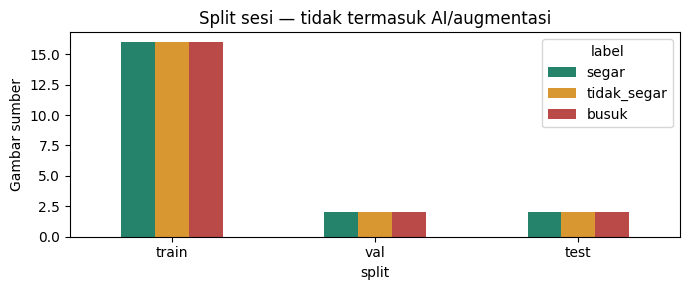

In [3]:
from src.manifest import load_bundle
from src.config import CLASS_NAMES, ExperimentConfig
BUNDLE = "data/prepared/7d208f30a6b6e8d7"
frame, metadata = load_bundle(BUNDLE)
assert frame.groupby("group_id").split.nunique().max() == 1
assert frame.sha256.is_unique
counts = pd.crosstab(frame.split, frame.label).reindex(["train", "val", "test"])[CLASS_NAMES]
display(counts)
print("Fingerprint:", metadata["fingerprint"])
counts.plot.bar(rot=0, color=["#25836b", "#d99732", "#b94a48"], figsize=(7, 3))
plt.ylabel("Gambar sumber"); plt.title("Split sesi — tidak termasuk AI/augmentasi"); plt.tight_layout(); plt.show()

## 4. Preprocessing dan contoh training
EXIF → RGB → letterbox 128 × 128 → float32 [0,1]. Hanya contoh training ditampilkan. Label kondisi visual tidak menjamin keamanan pangan.

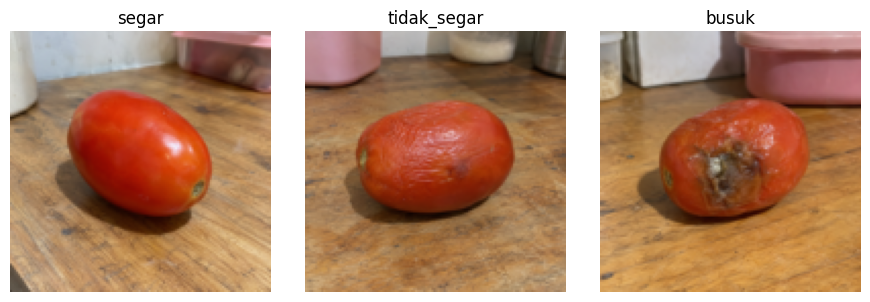

In [4]:
from src.preprocessing import load_image, load_arrays
train = frame[frame.split.eq("train")]
validation = frame[frame.split.eq("val")]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, label in zip(axes, CLASS_NAMES):
    sample = train[train.label.eq(label)].iloc[0]
    image = load_image(sample.filepath)
    assert image.shape == (128, 128, 3) and image.dtype == np.float32
    assert 0 <= image.min() <= image.max() <= 1
    ax.imshow(image); ax.set_title(label); ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Arsitektur neural network
CNN regularized memakai residual separable convolution dan Group Normalization. Baseline memakai empat blok Conv–BatchNorm–ReLU–MaxPool. Keduanya dilatih dari bobot acak. Augmentasi berjalan hanya saat training.

In [5]:
from src.model import build_model
import tensorflow as tf
tf.config.threading.set_inter_op_parallelism_threads(2)
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.keras.utils.set_random_seed(42)
model = build_model(config=ExperimentConfig(epochs=20, train_samples_per_class=120))
model.summary()
print("TensorFlow:", tf.__version__, "parameter:", model.count_params())

Model: "tomato_regularized_scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_0_to_1          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ training_augmentat… │ (None, 128, 128,  │          0 │ rgb_0_to_1[0][0]  │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ training_augment… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        648 │ re_lu[0][0]       │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalization │ (None, 64, 64,    │         48 │ conv2d[0][0]      │
│ (GroupNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ group_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 64,    │      1,368 │ activation[0][0]  │
│ (SeparableConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 64, 64,    │         96 │ separable_conv2d… │
│ (GroupNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ group_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 32, 32,    │      2,736 │ activation_1[0][… │
│ (SeparableConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 32, 32,    │         96 │ separable_conv2d… │
│ (GroupNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      1,152 │ activation[0][0]  │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ group_normalizat… │
│                     │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 32, 32,    │          0 │ activation_2[0][… │
│ (SpatialDropout2D)  │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 32, 32,    │      5,040 │ spatial_dropout2… │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 32, 32,    │        192 │ separable_conv2d

 Total params: 96,019 (375.07 KB)

 Trainable params: 96,019 (375.07 KB)

 Non-trainable params: 0 (0.00 B)

TensorFlow: 2.16.1 parameter: 96019


## 6. Training dua kandidat yang dapat diulang
Sel ini berisi training nyata, tetapi default memuat artefak eksperimen tersimpan agar Run All cepat. Aktifkan flag untuk training ulang. Output baru tidak menimpa model sebelumnya. Epoch sampling 120/kelas adalah pengulangan dari 16 sumber training/kelas, bukan 360 buah baru.

In [6]:
RUN_TRAINING = False
RUN_ROOT = ROOT / "outputs/experiments/own_v3_augmented"
if RUN_TRAINING:
    from datetime import datetime
    from src.train import train_run
    RUN_ROOT = ROOT / "outputs/experiments" / ("notebook_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
    train_run(BUNDLE, RUN_ROOT / "regularized", ExperimentConfig(epochs=20, train_samples_per_class=120))
    train_run(BUNDLE, RUN_ROOT / "baseline_augmented", ExperimentConfig.load("configs/augmented_baseline.json"))
else:
    print("Training ulang dilewati; memakai model dan history tersimpan.")
runs = {name: json.loads((RUN_ROOT / name / "run.json").read_text()) for name in ["regularized", "baseline_augmented"]}
comparison = pd.DataFrame([dict(model=name, parameters=r["model_parameters"], epochs=r["epochs_run"],
    best_epoch=r["best_epoch"], train_accuracy=r["train_clean"]["accuracy"],
    val_accuracy=r["validation"]["accuracy"], val_macro_f1=r["validation"]["macro_f1"], val_loss=r["validation"]["loss"])
    for name, r in runs.items()])
display(comparison)
selected = sorted(runs, key=lambda name: (-runs[name]["validation"]["macro_f1"], runs[name]["validation"]["loss"]))[0]
print("Terpilih dari validation:", selected, "— test tidak dinilai.")

Training ulang dilewati; memakai model dan history tersimpan.


,model,parameters,epochs,best_epoch,train_accuracy,val_accuracy,val_macro_f1,val_loss
0,regularized,96019,20,15,0.8125,0.666667,0.655556,0.538376
1,baseline_augmented,423619,19,9,0.9375,0.666667,0.655556,0.904118


Terpilih dari validation: regularized — test tidak dinilai.


## 7. Learning curves

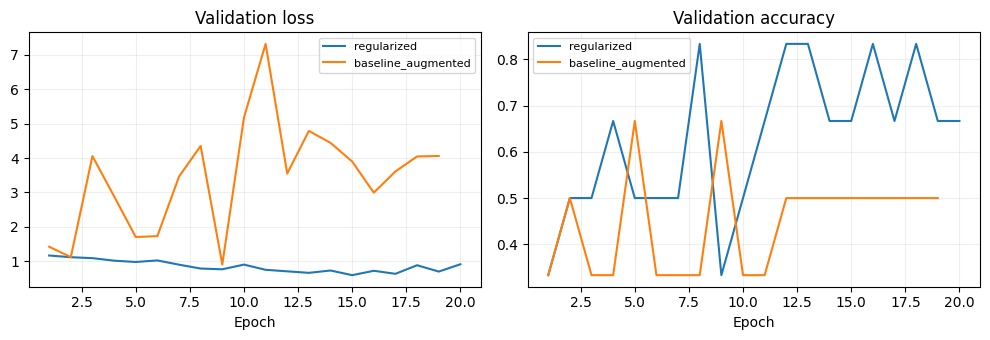

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for name in runs:
    history = json.loads((RUN_ROOT / name / "history.json").read_text())
    epochs = np.arange(1, len(history["loss"]) + 1)
    axes[0].plot(epochs, history["val_loss"], label=name)
    axes[1].plot(epochs, history["val_accuracy"], label=name)
axes[0].set_title("Validation loss"); axes[1].set_title("Validation accuracy")
for ax in axes: ax.set_xlabel("Epoch"); ax.legend(fontsize=8); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## 8. Evaluasi ulang pada validation
Accuracy, precision, recall, macro-F1, confusion matrix, dan ECE dihitung dari prediksi model tersimpan. Validation ini juga digunakan untuk early stopping dan seleksi sehingga bukan estimasi test independen.

accuracy 0.666667
macro_precision 0.722222
macro_recall 0.666667
macro_f1 0.655556
expected_calibration_error 0.286777


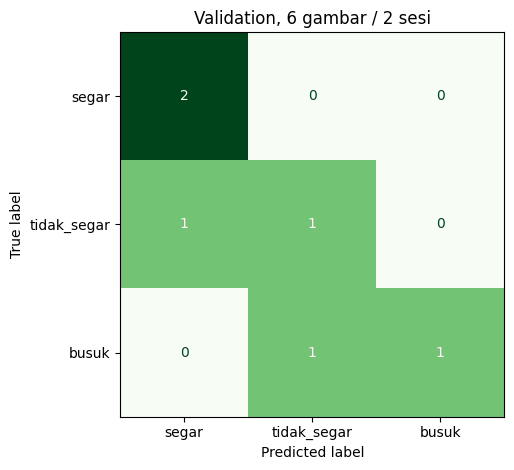

In [8]:
from src.evaluate import metrics, predict_batches
loaded = tf.keras.models.load_model(RUN_ROOT / selected / "model.keras", compile=False)
x_val, y_val = load_arrays(validation)
probabilities = predict_batches(loaded, x_val)
result = metrics(y_val, probabilities)
for key in ["accuracy", "macro_precision", "macro_recall", "macro_f1", "expected_calibration_error"]:
    print(key, round(result[key], 6))
assert abs(result["accuracy"] - runs[selected]["validation"]["accuracy"]) < 1e-6
assert abs(result["macro_f1"] - runs[selected]["validation"]["macro_f1"]) < 1e-6
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(np.array(result["confusion_matrix"]), display_labels=CLASS_NAMES).plot(cmap="Greens", colorbar=False)
plt.title("Validation, 6 gambar / 2 sesi"); plt.tight_layout(); plt.show()

## 9. Analisis kesalahan dan batas generalisasi

In [9]:
errors = validation[["filepath", "label", "group_id"]].copy()
errors["prediction"] = [CLASS_NAMES[i] for i in probabilities.argmax(axis=1)]
errors["confidence"] = probabilities.max(axis=1)
display(errors[errors.label.ne(errors.prediction)])
print("Satu kesalahan dari 6 gambar mengubah accuracy sebesar 16,7 poin persentase.")
print("300 file tidak sama dengan 300 sampel primer berlabel; 218 sintetis dan 22 impor belum disetujui.")
print("Hasil own_v1 100% tidak digunakan: ada kebocoran sesi. Test terkunci belum dinilai pada eksperimen ini.")

,filepath,label,group_id,prediction,confidence
47,data/raw/TOM048_tidak_segar.png,tidak_segar,own:b08_beton,segar,0.745741
58,data/raw/TOM059_busuk.png,busuk,own:b09_kayu_gelap,tidak_segar,0.541837


Satu kesalahan dari 6 gambar mengubah accuracy sebesar 16,7 poin persentase.
127 file tidak sama dengan 127 sampel primer berlabel; 45 AI dan 22 impor belum disetujui.
Hasil own_v1 100% tidak digunakan: ada kebocoran sesi. Test terkunci belum dinilai pada eksperimen ini.


## 10. Inferensi satu gambar
Ganti `PHOTO` dengan file yang ingin diprediksi. Contoh default berasal dari validation, sehingga bukan bukti uji eksternal. Tidak ada perubahan label otomatis.

In [10]:
PHOTO = validation.iloc[0].filepath
single = predict_batches(loaded, np.expand_dims(load_image(PHOTO), 0))[0]
display(pd.DataFrame({"kelas": CLASS_NAMES, "probabilitas": single}))
print("Dugaan:", CLASS_NAMES[int(single.argmax())])

,kelas,probabilitas
0,segar,0.776160
1,tidak_segar,0.219426
2,busuk,0.004413


Dugaan: segar


## 11. Prediksi selektif: risiko dan cakupan
Ambang tetap 0,7 berasal dari konfigurasi aplikasi, bukan hasil optimasi pada validation. Kasus yang dirujuk tidak dihitung sebagai prediksi benar. Hasil ini eksploratif pada enam gambar validation.

In [ ]:
from src.selective_evaluation import selective_summary
from src.predict import Predictor
predictor = Predictor(RUN_ROOT / selected)
details = [predictor.predict(path) for path in validation.filepath]
predicted = np.array([CLASS_NAMES.index(d["label"]) for d in details])
confidence = np.array([d["confidence"] for d in details])
policies = {
    "Semua prediksi": np.ones(len(y_val), dtype=bool),
    "Confidence >= 0.7": confidence >= predictor.review_threshold,
    "Confidence + quality + consistency": np.array([not d["needs_review"] for d in details]),
}
display(pd.DataFrame({name: selective_summary(y_val, predicted, mask) for name, mask in policies.items()}).T)
curve = pd.DataFrame([{"threshold": float(t), **selective_summary(y_val, predicted, confidence >= t)} for t in np.linspace(0, 1, 21)])
curve.dropna(subset=["selective_risk"]).plot(x="coverage", y="selective_risk", marker="o", legend=False, figsize=(5, 3))
plt.xlabel("Coverage"); plt.ylabel("Risiko pada prediksi diterima"); plt.title("Validation deskriptif — tanpa tuning ambang"); plt.tight_layout(); plt.show()

## 12. Variasi kondisi pengambilan gambar
Manifest mencatat kondisi yang diminta dalam prompt: basah/kering, fokus/blur, jarak, cahaya, sudut, bentuk, dan latar. Atribut tersebut belum merupakan pengukuran visual ground truth. Kondisi dibuat lintas kelas untuk mengurangi keterkaitan latar dengan label. Data baru belum dipakai melatih model di notebook ini.

In [ ]:
variations = pd.read_csv(DATA / "variation_manifest.csv")
assert len(variations) == 218 and variations.pixel_sha256.is_unique
for factor in ["surface_moisture", "focus_condition", "subject_scale"]:
    print(factor)
    display(pd.crosstab(variations[factor], variations.label))
print("Kondisi yang tidak tercatat pada batch lama ditandai secara eksplisit.")

## 13. Reproduksi, deployment, dan presentasi

- Aplikasi TensorFlow lokal: `python -m src.app --run outputs/experiments/own_v3_augmented/regularized`.
- Inferensi CLI: `python -m src.predict foto.jpg --run outputs/experiments/own_v3_augmented/regularized`.
- Laporan terbaru: `submission/IS794_Laporan_TomatoVision.docx`.
- PPT final dan Week 7: `submission/presentasi/`.
- Audit ketentuan dan rencana akuisisi: `submission/audit/`.
- Jangan mengklaim model web lama sebagai hasil model regularized ini.
- Test final baru dijalankan setelah dataset primer, label, dan pemilihan model sudah final.
- AI membantu kode, dokumentasi, serta 218 gambar sintetis; verifikasi akademik dan kontribusi tetap tanggung jawab tim.
